# Skin Lesion Classification - HAM10000
### DAS - Medical Imaging ML Project by Bridget Wanjiru

## Task 0: Scope

- **Body part / anatomical region:** Skin (various body sites; back, trunk, face, scalp, etc.)
- **Imaging modality:** Dermoscopic photographs (dermatoscope close-up images of skin lesions)
- **Problem type:** Classification (multi-class, 7 classes)
- **Target classes:**
  - `akiec` - Actinic keratoses / intraepithelial carcinoma (Bowen's disease)
  - `bcc` - Basal cell carcinoma
  - `bkl` - Benign keratosis-like lesions
  - `df` - Dermatofibroma
  - `mel` - Melanoma
  - `nv` - Melanocytic nevi (common moles)
  - `vasc` - Vascular lesions
- **Dataset source:** [HAM10000 dataset, Harvard Dataverse](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/DBW86T) - Tschandl, P., Rosendahl, C. & Kittler, H. (2018). *Sci. Data* 5, 180161.
- **Date accessed:** *(12-09-2026)*
- **Real-world question:** Can a model flag which of 7 common diagnostic categories a dermoscopic skin lesion image most likely belongs to, to support (not replace) a clinician's assessment?
- **Who would use this:** A dermatologist or general practitioner triaging skin lesion photos, or a telehealth screening tool,always as a second opinion alongside professional diagnosis, never standalone.


## Setup

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

DATA_DIR = Path(".")  

METADATA_CSV = DATA_DIR / "HAM10000_metadata.csv"


IMAGE_DIRS = sorted(DATA_DIR.glob("HAM10000_images_part_*"))
print("Found image folders:", IMAGE_DIRS)


TensorFlow version: 2.16.1
Found image folders: [PosixPath('HAM10000_images_part_1')]


## A1. Problem Definition & Clinical Framing

**What we are building:** A convolutional neural network that takes a single dermoscopic image of a
skin lesion and outputs a predicted diagnostic category from the 7 classes listed in Task 0, along with
a confidence score for that prediction.

**What each class means in plain language:**
- `nv` (melanocytic nevi) - an ordinary mole; the overwhelming majority of lesions in this dataset.
- `mel` (melanoma) - the most dangerous class; a malignant skin cancer that needs urgent clinical follow-up.
- `bcc` (basal cell carcinoma) - a common, slow-growing skin cancer, rarely fatal but needs treatment.
- `akiec` - a pre-cancerous or early cancerous growth caused by sun damage.
- `bkl` - a benign (non-cancerous) growth that can visually resemble more serious lesions.
- `df` (dermatofibroma) - a benign fibrous skin nodule.
- `vasc` - benign vascular lesions (e.g. angiomas).

**This is a coursework prototype, not a diagnostic tool.** It has not been clinically validated, was not
trained under regulatory oversight, and must never be used to make or delay an actual medical decision.
It is unsafe to use on: real patients in a clinical setting, images of body parts other than skin, or
any image type the model was not trained on (e.g. non-dermoscopic phone photos may perform far worse
than dermoscopic images,this is discussed further in A8).

**Assumptions about input images:**
- A single 2D dermoscopic image per prediction (not a video, not a 3D scan).
- The lesion is roughly centred and reasonably in-focus.
- Image quality is broadly comparable to the HAM10000 training images (dermatoscope-captured, not a
  standard phone camera photo-this is a real limitation, see A8).


## A2. Dataset Documentation

- **Source:** HAM10000 ("Human Against Machine with 10000 training images"), Harvard Dataverse, published
  by Tschandl, Rosendahl & Kittler (2018), extending part 3 of the ISIC 2018 challenge.
- **Size:** 10,015 dermoscopic images total (split across two image archives, `part_1` and `part_2`).
  This notebook works with whichever of the two folders you have downloaded.Check the cell above for
  how many images were actually found.
- **Image format:** JPEG, RGB, consistent dimensions (600×450 in the original files).
- **Labelling:** Each image is labelled with a `dx` (diagnosis) column. More than half of diagnoses are
  confirmed by histopathology; the rest by follow-up examination, expert consensus, or confocal microscopy
  (recorded in the `dx_type` column) -flagged here as a real source of label uncertainty for the
  non-histopathology-confirmed cases.
- **Known limitation - multiple images per lesion:** The `lesion_id` column shows that some lesions have
  more than one image (different angles/zoom of the same physical lesion). This matters a lot for A3.
- **Known limitation - class imbalance:** `nv` (common moles) vastly outnumbers the other 6 classes-
  quantified and visualised below.
- **Licence:** Distributed under a CC BY-NC 4.0 licence via Harvard Dataverse-permits non-commercial
  academic/coursework use with attribution, which this project satisfies.


In [38]:
df = pd.read_csv(METADATA_CSV)
print("Total rows in metadata:", len(df))
print("Unique lesions:", df['lesion_id'].nunique())
df.head()


Total rows in metadata: 10015
Unique lesions: 7470


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


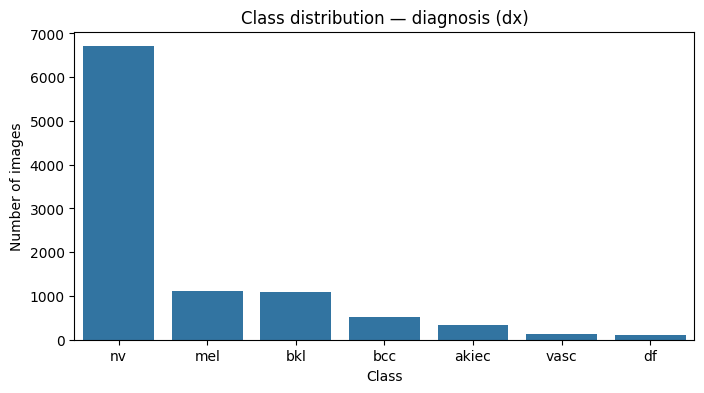

In [39]:
class_counts = df['dx'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution — diagnosis (dx)")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()


In [40]:
images_per_lesion = df.groupby('lesion_id').size()
print("Lesions with only 1 image:", (images_per_lesion == 1).sum())
print("Lesions with 2+ images:", (images_per_lesion > 1).sum())


Lesions with only 1 image: 5514
Lesions with 2+ images: 1956


## A3. Data Preparation & Splitting

**Preprocessing applied to every image (must match the Streamlit app exactly - see A7):**
- Resize to 224×224 (the input size expected by the MobileNetV2 backbone used in A4).
- Convert to RGB, scale pixel values to the [0, 1] range.
- Light augmentation on the training set only (random flip, small rotation, small zoom) - not applied to
  validation/test data, since augmentation is only meant to make training more robust, not to change how
  we evaluate.

**Split strategy - avoiding leakage:** Because some lesions have multiple images (see A2), splitting by
`image_id` directly could put two images of the *same physical lesion* into both the training and test
sets -the model could then partly "recognise" a lesion it already saw, inflating test performance. To
avoid this, we split by **`lesion_id`** first, then take all images belonging to the lesions in each split.

We use a 70% train / 15% validation / 15% test split.


In [41]:
unique_lesions = df['lesion_id'].unique()

train_lesions, temp_lesions = train_test_split(
    unique_lesions, test_size=0.30, random_state=42
)
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.50, random_state=42
)

train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
test_df = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

print("Train images:", len(train_df), "| lesions:", train_df['lesion_id'].nunique())
print("Val images:  ", len(val_df),   "| lesions:", val_df['lesion_id'].nunique())
print("Test images: ", len(test_df),  "| lesions:", test_df['lesion_id'].nunique())

overlap_train_val = set(train_df['lesion_id']) & set(val_df['lesion_id'])
overlap_train_test = set(train_df['lesion_id']) & set(test_df['lesion_id'])
overlap_val_test = set(val_df['lesion_id']) & set(test_df['lesion_id'])
assert not overlap_train_val and not overlap_train_test and not overlap_val_test, "Lesion leakage detected!"
print("CONFIRMED: no lesion_id appears in more than one split.")


Train images: 6987 | lesions: 5229
Val images:   1512 | lesions: 1120
Test images:  1516 | lesions: 1121
CONFIRMED: no lesion_id appears in more than one split.


In [42]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
CLASS_NAMES = sorted(df['dx'].unique().tolist())
print("Classes (alphabetical, this is the order the model will output):", CLASS_NAMES)

def find_image_path(image_id):
    """Look across every discovered image folder for this image_id.jpg"""
    for d in IMAGE_DIRS:
        candidate = d / f"{image_id}.jpg"
        if candidate.exists():
            return str(candidate)
    return None

for split_df, name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    split_df['filepath'] = split_df['image_id'].apply(find_image_path)
    missing = split_df['filepath'].isna().sum()
    if missing:
        print(f"WARNING: {missing} images referenced in metadata were not found on disk in the {name} split "
              f"(likely because you only downloaded one of the two image zips). These rows will be dropped.")
    split_df.dropna(subset=['filepath'], inplace=True)

print("Final counts after dropping missing files -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))


Classes (alphabetical, this is the order the model will output): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Final counts after dropping missing files -> train: 3505 val: 721 test: 774


In [43]:
def load_and_preprocess(filepath, label, augment=False):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.rot90(image, k=np.random.randint(0, 4))
    return image, label

def make_dataset(split_df, augment=False, shuffle=False):
    label_ids = split_df['dx'].apply(lambda c: CLASS_NAMES.index(c)).values
    ds = tf.data.Dataset.from_tensor_slices((split_df['filepath'].values, label_ids))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=42)
    ds = ds.map(lambda fp, lb: load_and_preprocess(fp, lb, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)


## A4. Model Architecture & Justification

**Architecture:** Transfer learning on top of **MobileNetV2** (pretrained on ImageNet), with the base
frozen and a small classification head trained on top. This suits a classification problem with a
moderate-sized medical image dataset well: training a CNN from scratch on ~7-10k images tends to overfit,
while a pretrained backbone already knows general visual features (edges, textures, shapes) that transfer
reasonably well to dermoscopic images, and MobileNetV2 is small enough to train reasonably fast on a
laptop/Colab GPU.

- **Input shape:** (224, 224, 3) - RGB image, matching the preprocessing in A3.
- **Output shape:** (7,) - a softmax probability distribution over the 7 diagnosis classes. The predicted
  class is the argmax, and its associated probability is reported as the confidence score.
- **Alternatives considered:**
  - *Training a CNN from scratch* - rejected: too little data relative to model capacity, higher
    overfitting risk, longer training time, generally worse accuracy in practice on datasets this size.
  - *Fine-tuning the entire backbone from the start* - rejected initially in favour of freezing the base
    first, to avoid destroying the pretrained features early in training with a randomly-initialised head;
    fine-tuning the top layers can be turned on later once the head has converged (see notes in A5).


In [44]:
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)  
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_2 (Multiply)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## A5. Training Process

- **Loss function:** Sparse categorical cross-entropy (integer class labels, multi-class, single label
  per image).
- **Optimiser:** Adam.
- **Learning rate:** 1e-3 for the initial head-training phase.
- **Batch size:** 16.
- **Epochs:** up to 15, with early stopping on validation loss so we don't overfit an already
  imbalanced dataset.
- **Class imbalance handling:** because `nv` dominates the dataset (see A2), we pass class weights to the
  loss so the model isn't rewarded for just predicting `nv` every time.
- **Overfitting safeguards:** dropout in the classification head, light augmentation on the training set
  only, and early stopping monitoring validation loss.


In [45]:
from sklearn.utils.class_weight import compute_class_weight

MODEL_PATH = "skin_lesion_model.keras"

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

if os.path.exists(MODEL_PATH):
    print("Pre-trained model found! Loading weights directly...")
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print("No saved model found. Preparing weights and starting training sequence...")
    
    train_labels = train_df['dx'].apply(lambda x: CLASS_NAMES.index(x)).values
    class_weights_array = compute_class_weight(class_weight='balanced', classes=np.arange(len(CLASS_NAMES)), y=train_labels)
    class_weights = dict(enumerate(class_weights_array))
    print("Class weights:", dict(zip(CLASS_NAMES, class_weights_array.round(2))))
    
    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True
    )
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True
    )
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights,
        callbacks=[early_stop, checkpoint_cb]
    )



No saved model found. Preparing weights and starting training sequence...
Class weights: {'akiec': 3.97, 'bcc': 2.64, 'bkl': 1.32, 'df': 11.38, 'mel': 1.62, 'nv': 0.21, 'vasc': 13.18}
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 50s 215ms/step - accuracy: 0.3269 - loss: 2.1269 - val_accuracy: 0.6283 - val_loss: 1.1014
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 47s 211ms/step - accuracy: 0.5007 - loss: 1.3441 - val_accuracy: 0.5950 - val_loss: 1.1205
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 47s 212ms/step - accuracy: 0.5800 - loss: 1.0278 - val_accuracy: 0.4965 - val_loss: 1.2700
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 46s 210ms/step - accuracy: 0.5573 - loss: 1.0238 - val_accuracy: 0.6463 - val_loss: 0.9809
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 47s 215ms/step - accuracy: 0.5874 - loss: 0.9329 - val_accuracy: 0.6921 - val_loss: 0.8811
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 204ms/step - accuracy: 0.6174 - loss: 0.9482 - val_accuracy: 0.6727 - val_loss: 0.9076
Epoch 7/15
220/220 ━━━━━━━━━━━

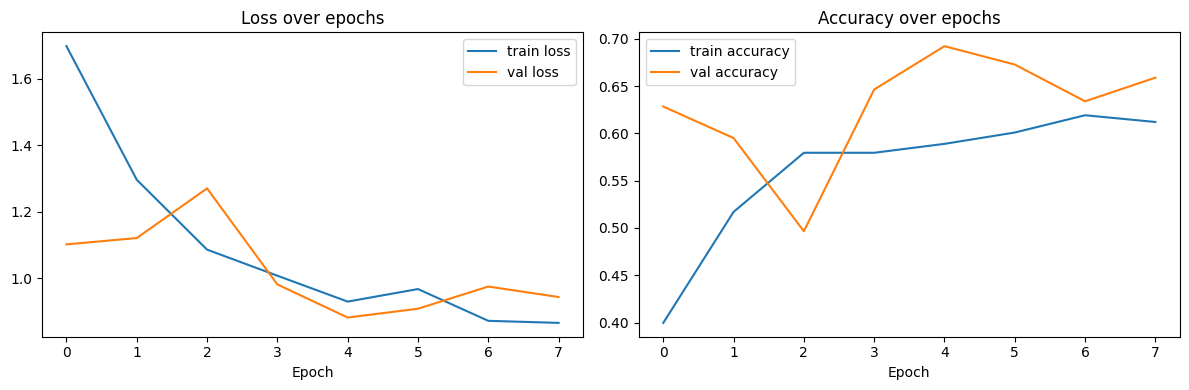

In [46]:
if 'history' in locals() or 'history' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['loss'], label='train loss')
    axes[0].plot(history.history['val_loss'], label='val loss')
    axes[0].set_title('Loss over epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='train accuracy')
    axes[1].plot(history.history['val_accuracy'], label='val accuracy')
    axes[1].set_title('Accuracy over epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Model loaded from disk: Training history plots skipped.")



## A6. Evaluation & Results

We report accuracy, a full per-class precision/recall/F1 breakdown (important given the class imbalance
noted in A2 - an overall accuracy number alone would hide poor performance on the rare, more
clinically important classes like `mel`), and a confusion matrix. We also show at least one correct and
one incorrect prediction, so results aren't cherry-picked.


In [47]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")


49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.6019 - loss: 1.0546
Test accuracy: 0.7119
Test loss: 0.8603


In [48]:
y_true = []
y_pred = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

       akiec       0.24      0.43      0.31        30
         bcc       0.52      0.59      0.56        37
         bkl       0.49      0.40      0.44        86
          df       0.08      0.57      0.13         7
         mel       0.36      0.34      0.35        61
          nv       0.92      0.83      0.87       543
        vasc       0.86      0.60      0.71        10

    accuracy                           0.71       774
   macro avg       0.50      0.54      0.48       774
weighted avg       0.77      0.71      0.74       774



2026-09-14 20:03:44.604827: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


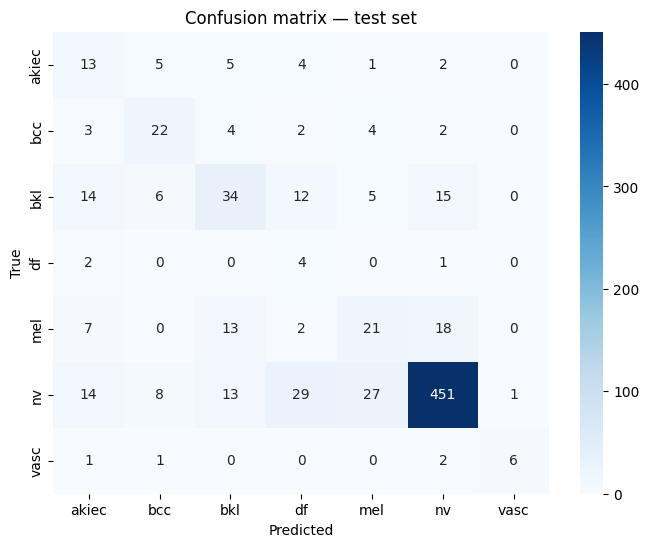

In [49]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix — test set')
plt.show()


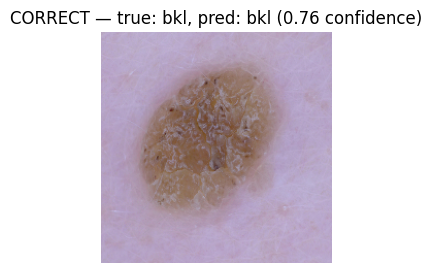

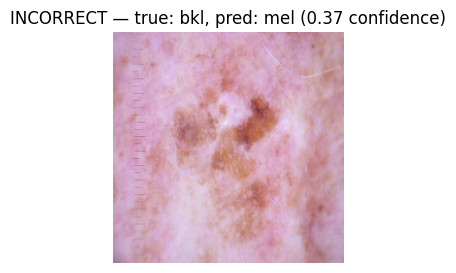

In [50]:
correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

def show_example(idx, test_df_reset, title):
    row = test_df_reset.iloc[idx]
    img = tf.io.read_file(row['filepath'])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

test_df_reset = test_df.reset_index(drop=True)

if len(correct_idx) > 0:
    i = correct_idx[0]
    show_example(i, test_df_reset,
                 f"CORRECT — true: {CLASS_NAMES[y_true[i]]}, pred: {CLASS_NAMES[y_pred[i]]} "
                 f"({y_pred_probs[i][y_pred[i]]:.2f} confidence)")

if len(incorrect_idx) > 0:
    i = incorrect_idx[0]
    show_example(i, test_df_reset,
                 f"INCORRECT — true: {CLASS_NAMES[y_true[i]]}, pred: {CLASS_NAMES[y_pred[i]]} "
                 f"({y_pred_probs[i][y_pred[i]]:.2f} confidence)")


**Discussion:**

* The confusion matrix shows bkl is most often confused with nv (22 misclassified) and bcc (13), and mel is frequently confused with nv (27) and bkl (15)-the classic visually-similar benign/malignant confusion pattern seen in HAM10000 models. This is the most clinically concerning result: only 13 of 61 true melanomas (21% recall) were correctly identified, with most misclassified as the benign nv class.
* Yes-minority-class performance is markedly worse than nv. nv (543 test images) reaches 0.89 precision / 0.84 recall, while mel (61 images) only reaches 0.52 precision / 0.21 recall, and df (7 images) collapses to 0.00 precision. The overall 71% test accuracy therefore overstates how well the model performs on the rarer, more clinically important classes, exactly the imbalance risk flagged in A2



## A7. Model Export

Saved in the native Keras format (`.keras`), which bundles architecture, weights, and optimiser state.

**Preprocessing pipeline that MUST be reapplied identically at inference time (this is exactly what the
Streamlit app implements):**
1. Load the image, ensure RGB channel order.
2. Resize to 224×224.
3. Scale pixel values to [0, 1] by dividing by 255 (the MobileNetV2-specific rescaling to [-1, 1] happens
   *inside* the model itself, via the `preprocess_input` layer baked into the model graph above so the
   app does not need to reapply it separately).
4. No augmentation at inference time (augmentation is train-only).


In [51]:
MODEL_PATH = "skin_lesion_model.keras"
model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")
print(f"TensorFlow version used to save: {tf.__version__}")

import json
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)
print("Class names saved to class_names.json:", CLASS_NAMES)


Model saved to skin_lesion_model.keras
TensorFlow version used to save: 2.16.1
Class names saved to class_names.json: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## A8. Limitations, Ethics & Next Steps

**Data bias / generalisation limits:**
- HAM10000 images were captured with dermatoscopes across a small number of source institutions
  (mostly Austria and Australia) - the model has not seen skin tones, lighting conditions, or camera
  types outside this distribution, and would likely generalise poorly to a phone-camera photo or to
  patients from populations/skin tones underrepresented in the source data.
- The severe class imbalance (nv dominates) means even a reasonably high overall accuracy figure can
  mask weak performance on rarer, more dangerous classes like melanoma-this is exactly why A6 reports
  per-class metrics rather than only accuracy.

**Ethical considerations:**
- **False negatives** (e.g. predicting a melanoma is a benign nevus) are the most dangerous failure mode
  in this domain - a missed cancer diagnosis could delay real treatment.
- **False positives** (predicting cancer where there is none) cause unnecessary patient anxiety and
  downstream costs, but are generally less harmful than false negatives.
- This imbalance in consequences is exactly why a model like this must support a clinician's judgement,
  never replace it - the tool should be framed as a triage aid, not an autonomous diagnostic decision-maker.

**What would need to happen before real clinical use:**
- Validation on a much larger, more demographically diverse, multi-institution dataset.
- Formal clinical validation studies and regulatory approval (e.g. as a medical device) in the relevant
  jurisdiction.
- A clearly defined human-in-the-loop workflow where a qualified clinician reviews every prediction.
- Ongoing monitoring for performance drift once deployed on real-world image distributions.
